# Citation support → correctness: the three preregistered confirmatory hypotheses

This notebook renders the study's three **preregistered confirmatory** hypotheses (A1, B1, C1) as one two-panel figure plus a results table. All three test *citation support → correctness*, but they differ in unit and estimand, so the figure keeps them on separate rows and annotates each with its unit/denominator.

| | Hypothesis | Unit | IV |
|---|---|---|---|
| **A1** | support → **LLM** answer correct | question (3-rater, n=208) | **majority** vote of raters (≥½ saw ≥1 supporting citation) |
| **B1** | support → **physician final** correct | response, GEE clustered by reader | per-response any-support |
| **C1** | support → physician final correct, **unaided incorrect only** | response, GEE clustered by reader | per-response any-support |

A1 is a plain logistic (Wald) test — LLM correctness is fixed per question, so the question is the unit and clustering would be pseudoreplication. B1/C1 are GEE logistic with cluster-robust SEs by reader (`pid`). Statistics mirror `scripts/reader_study/analysis.py`. Exploratory analyses (A2/B2/C2, dose–response, automation bias) are deliberately excluded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Independence
from statsmodels.genmod.families import Binomial

RESPONSES = "../results/reader_study/responses.csv"
resp = pd.read_csv(RESPONSES)
print(f"{resp['pid'].nunique()} physicians · {len(resp)} responses · {resp['question_id'].nunique()} questions")

46 physicians · 736 responses · 288 questions


In [2]:
# ---- Estimators (identical spec to scripts/reader_study/analysis.py) ----

def logit_or(df, dv, iv):
    """Plain logistic (Wald) OR + 95% CI for a binary IV. Used for A1."""
    sub = df[[dv, iv]].dropna().astype({dv: int, iv: int})
    res = sm.Logit(sub[dv], sm.add_constant(sub[iv])).fit(disp=False)
    ci = res.conf_int().loc[iv]
    rates = sub.groupby(iv)[dv].mean()
    return dict(OR=np.exp(res.params[iv]), lo=np.exp(ci[0]), hi=np.exp(ci[1]),
                z=res.tvalues[iv], p=res.pvalues[iv], n=len(sub), k=None,
                rate0=rates.get(0, np.nan), rate1=rates.get(1, np.nan))

def gee_or(df, dv, iv, grp="pid"):
    """GEE logistic OR + cluster-robust 95% CI (clustered by reader). B1/C1."""
    sub = df[[dv, iv, grp]].dropna().astype({dv: int, iv: int})
    res = GEE(sub[dv], sm.add_constant(sub[iv]), groups=sub[grp],
              family=Binomial(), cov_struct=Independence()).fit()
    ci = res.conf_int().loc[iv]
    rates = sub.groupby(iv)[dv].mean()
    return dict(OR=np.exp(res.params[iv]), lo=np.exp(ci[0]), hi=np.exp(ci[1]),
                z=res.tvalues[iv], p=res.pvalues[iv], n=len(sub),
                k=sub[grp].nunique(),
                rate0=rates.get(0, np.nan), rate1=rates.get(1, np.nan))

# ---- A1: question-level, majority vote among 3-rater questions ----
g = resp.groupby("question_id")
q = pd.DataFrame({"n_raters": g.size(),
                  "support_frac": g["any_source_supports"].mean(),
                  "llm_is_correct": g["llm_is_correct"].first().astype(int)}).reset_index()
q3 = q[q["n_raters"] == 3].copy()
q3["maj_support"] = (q3["support_frac"] >= 0.5).astype(int)
A1 = logit_or(q3, "llm_is_correct", "maj_support")

# ---- B1: response-level, any-support, GEE by reader ----
B1 = gee_or(resp, "final_correct", "any_source_supports")

# ---- C1: response-level restricted to unaided-incorrect, GEE by reader ----
C1 = gee_or(resp[~resp["initial_correct"]], "final_correct", "any_source_supports")

ROWS = [
    dict(id="A1", res=A1, outcome="LLM answer correct",
         detail="majority voted citation support"),
    dict(id="B1", res=B1, outcome="Physician final answer correct",
         detail=""),
    dict(id="C1", res=C1, outcome="Physician final answer correct",
         detail="initially incorrect only"),
]
for r in ROWS:
    print(r["id"], {k: (round(v, 3) if isinstance(v, float) else v) for k, v in r["res"].items()})

A1 {'OR': 6.76, 'lo': 2.725, 'hi': 16.768, 'z': 4.123, 'p': 0.0, 'n': 192, 'k': None, 'rate0': 0.658, 'rate1': 0.929}
B1 {'OR': 3.751, 'lo': 2.48, 'hi': 5.675, 'z': 6.26, 'p': 0.0, 'n': 736, 'k': 46, 'rate0': 0.655, 'rate1': 0.877}
C1 {'OR': 5.792, 'lo': 2.819, 'hi': 11.904, 'z': 4.78, 'p': 0.0, 'n': 215, 'k': 45, 'rate0': 0.239, 'rate1': 0.646}


## Results table

In [3]:
def fmt_p(p):
    return "<0.001" if p < 1e-3 else f"{p:.3f}"

def unit_str(r):
    res = r["res"]
    base = f"n={res['n']}"
    return base + (f" ({res['k']} readers)" if res["k"] else "")

tbl = pd.DataFrame([{
    "": r["id"],
    "Outcome": r["outcome"],
    "Unit": unit_str(r),
    "Correct | not supported": f"{r['res']['rate0']*100:.1f}%",
    "Correct | supported": f"{r['res']['rate1']*100:.1f}%",
    "OR (95% CI)": f"{r['res']['OR']:.2f} ({r['res']['lo']:.2f}–{r['res']['hi']:.2f})",
    "p": fmt_p(r["res"]["p"]),
} for r in ROWS]).set_index("")
tbl

,Outcome,Unit,Correct | not supported,Correct | supported,OR (95% CI),p
,,,,,,
A1,LLM answer correct,n=192,65.8%,92.9%,6.76 (2.73–16.77),<0.001
B1,Physician final answer correct,n=736 (46 readers),65.5%,87.7%,3.75 (2.48–5.67),<0.001
C1,Physician final answer correct,n=215 (45 readers),23.9%,64.6%,5.79 (2.82–11.90),<0.001


## Figure

Two panels sharing the A1/B1/C1 rows:

- **Left — probability scale** (a dumbbell per hypothesis): correctness rate when citations do *not* support the answer vs. when ≥1 does.
- **Right — the confirmatory test** (forest plot): odds ratio with 95% CI on a log axis, reference line at OR = 1.

Titles/subtitles are omitted — the axis labels carry the meaning and the rest goes in the caption.

### Palette chooser
The first cell below previews the left panel in six candidate two-color schemes (each CVD-checked with the dataviz validator). Look them over, then set `PALETTE` in the chooser cell to the one you like — the final cell renders and saves the full figure as a PNG to `../plots/reader_study/`.

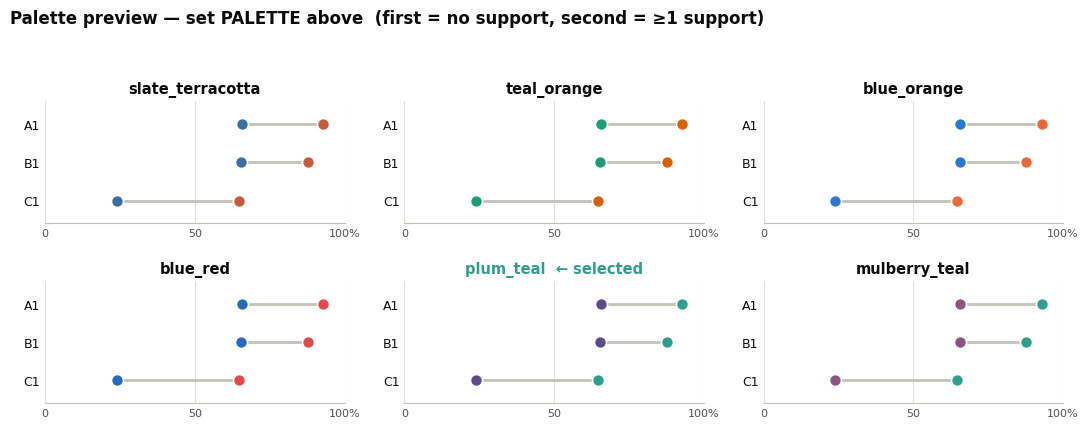

In [4]:
# ── Colour scheme ──────────────────────────────────────────────────────────────
# tuple = (no-support colour, ≥1-support colour). All six PASS every dataviz CVD
# check (separation, normal-vision floor, and 3:1 surface contrast) in light mode.
PALETTES = {
    'slate_terracotta': ('#3b6ea5', '#c65b3c'),  # muted slate-blue + terracotta (soft, publication)
    'teal_orange':      ('#1b9e77', '#d95f02'),  # teal + burnt-orange (ColorBrewer Dark2, editorial)
    'blue_orange':      ('#2a78d6', '#eb6834'),  # crisp blue + orange (vivid, classic)
    'blue_red':         ('#256abf', '#e34948'),  # blue + red (strong, diverging feel)
    'plum_teal':        ('#5b4b8a', '#2e9e8f'),  # muted plum + teal (elegant, low-key)
    'mulberry_teal':    ('#8c5383', '#2f9e8f'),  # mulberry + teal (sophisticated)
}
PALETTE = 'plum_teal'   # <- change this to any key above

# ---- shared style constants ----
INK, INK2, GRID, AXIS = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "font.size": 15, "text.color": INK,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK, "svg.fonttype": "none",
})

y = np.array([2, 1, 0])   # A1 top, C1 bottom

# ---- preview: the probability panel rendered in every candidate palette ----
import math
_names = list(PALETTES)
_ncol = 3
_nrow = math.ceil(len(_names) / _ncol)
gfig, gax = plt.subplots(_nrow, _ncol, figsize=(11, 2.2 * _nrow))
gax = np.atleast_1d(gax).ravel()
for ax, name in zip(gax, _names):
    unsup, sup = PALETTES[name]
    for yi, r in zip(y, ROWS):
        r0, r1 = r["res"]["rate0"] * 100, r["res"]["rate1"] * 100
        ax.plot([r0, r1], [yi, yi], color=AXIS, lw=2, zorder=1, solid_capstyle="round")
        ax.scatter([r0], [yi], s=75, color=unsup, edgecolor="white", lw=1.2, zorder=3)
        ax.scatter([r1], [yi], s=75, color=sup,   edgecolor="white", lw=1.2, zorder=3)
    ax.set(xlim=(0, 100), ylim=(-0.6, 2.6))
    ax.set_yticks(y)
    ax.set_yticklabels([r["id"] for r in ROWS], fontsize=9)
    ax.set_xticks([0, 50, 100])
    ax.set_xticklabels(["0", "50", "100%"], fontsize=8)
    picked = (name == PALETTE)
    ax.set_title(name + ("  ← selected" if picked else ""), fontsize=10.5,
                 fontweight="bold", pad=6, color=(sup if picked else INK))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color=GRID, lw=0.8)
for ax in gax[len(_names):]:
    ax.axis("off")
gfig.suptitle("Palette preview — set PALETTE above  (first = no support, second = ≥1 support)",
              x=0.008, ha="left", fontsize=12, fontweight="bold")
gfig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

Saved ../plots/reader_study/support_correctness_relationship.png  ·  palette: plum_teal  ('#5b4b8a', '#2e9e8f')


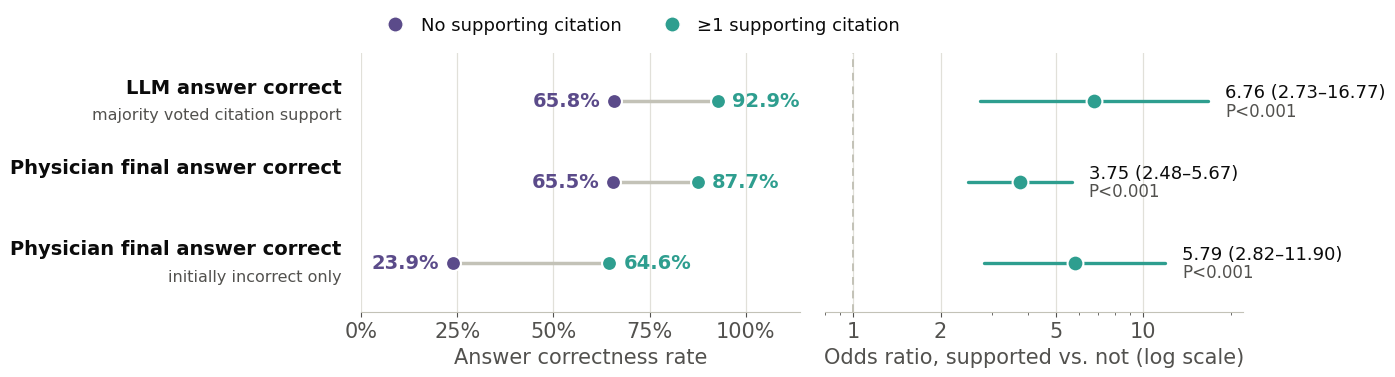

In [5]:
# ============================ Final figure (no titles) ============================
# Colour is chosen via PALETTE in the chooser cell above.
import os

OUT_DIR = "../plots/reader_study"   # relative to notebooks/ (matches the ../results/... paths above)

SHOW_GRID = True   # x-axis gridlines on/off

def make_figure(unsup, sup):
    fig, (axL, axR) = plt.subplots(
        1, 2, figsize=(11.6, 3.5), sharey=True,
        gridspec_kw=dict(width_ratios=[1.05, 1.0], wspace=0.06))

    # ---- LEFT: dumbbell (probability scale) ----
    for yi, r in zip(y, ROWS):
        r0, r1 = r["res"]["rate0"] * 100, r["res"]["rate1"] * 100
        axL.plot([r0, r1], [yi, yi], color=AXIS, lw=2.5, zorder=1, solid_capstyle="round")
        axL.scatter([r0], [yi], s=115, color=unsup, zorder=3, edgecolor="white", linewidth=1.5)
        axL.scatter([r1], [yi], s=115, color=sup,   zorder=3, edgecolor="white", linewidth=1.5)
        axL.annotate(f"{r0:.1f}%", (r0, yi), xytext=(-10, 0), textcoords="offset points",
                     ha="right", va="center", color=unsup, fontsize=14, fontweight="bold")
        axL.annotate(f"{r1:.1f}%", (r1, yi), xytext=(10, 0), textcoords="offset points",
                     ha="left", va="center", color=sup, fontsize=14, fontweight="bold")
    # Headroom past 100% so the value label on a high rate (92.9%) is not clipped
    # by the panel edge; ticks/grid still stop at 100%.
    axL.set_xlim(0, 114)
    axL.set_xticks(range(0, 101, 25))
    axL.set_xticklabels([f"{v}%" for v in range(0, 101, 25)])
    axL.set_xlabel("Answer correctness rate", color=INK2)
    if SHOW_GRID:
        axL.xaxis.grid(True, color=GRID, lw=0.9)
    axL.set_axisbelow(True)
    for s in ("top", "right", "left"):
        axL.spines[s].set_visible(False)
    axL.set_yticks([])
    axL.set_ylim(-0.6, 2.6)
    blend = mpl.transforms.blended_transform_factory(axL.transAxes, axL.transData)
    for yi, r in zip(y, ROWS):
        axL.text(-0.045, yi + 0.17, r["outcome"], transform=blend,
                 ha="right", va="center", fontsize=14, color=INK, fontweight="bold", clip_on=False)
        axL.text(-0.045, yi - 0.17, r["detail"], transform=blend,
                 ha="right", va="center", fontsize=11.5, color=INK2, clip_on=False)

    # ---- RIGHT: forest (odds ratio) ----
    axR.axvline(1, color=AXIS, lw=1.4, ls=(0, (4, 3)), zorder=1)
    for yi, r in zip(y, ROWS):
        res = r["res"]
        axR.plot([res["lo"], res["hi"]], [yi, yi], color=sup, lw=2.4, zorder=2, solid_capstyle="round")
        axR.scatter([res["OR"]], [yi], s=130, color=sup, zorder=3, edgecolor="white", linewidth=1.5)
        # OR (CI) on the first line, P-value on the second to keep the column narrow
        axR.annotate(f"{res['OR']:.2f} ({res['lo']:.2f}–{res['hi']:.2f})",
                     (res["hi"], yi), xytext=(12, 6), textcoords="offset points",
                     ha="left", va="center", color=INK, fontsize=13)
        axR.annotate(f"P{('=' if res['p']>=1e-3 else '')}{fmt_p(res['p'])}",
                     (res["hi"], yi), xytext=(12, -7), textcoords="offset points",
                     ha="left", va="center", color=INK2, fontsize=12)
    axR.set_xscale("log")
    axR.set_xlim(0.8, 22)
    axR.set_xticks([1, 2, 5, 10])
    axR.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
    axR.set_xlabel("Odds ratio, supported vs. not (log scale)", color=INK2)
    if SHOW_GRID:
        axR.xaxis.grid(True, color=GRID, lw=0.9)
    axR.set_axisbelow(True)
    for s in ("top", "right", "left"):
        axR.spines[s].set_visible(False)
    #axR.annotate("OR = 1", (1, 2.55), xytext=(4, 0), textcoords="offset points",
    #             ha="left", va="top", color=INK2, fontsize=11.5)

    # ---- legend (identity, since there are no titles) ----
    handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=unsup,
               markersize=11, markeredgecolor="white", label="No supporting citation"),
        Line2D([0], [0], marker="o", color="none", markerfacecolor=sup,
               markersize=11, markeredgecolor="white", label="≥1 supporting citation"),
    ]
    # Placed above the panels (figure coords) so both entries have room at this
    # font size; inside axL the two-column legend ran off the panel.
    fig.legend(handles=handles, loc="lower left", bbox_to_anchor=(0.235, 0.905),
               frameon=False, fontsize=13, handletextpad=0.4,
               ncol=2, columnspacing=1.8)

    fig.subplots_adjust(left=0.235, right=0.995, top=0.90, bottom=0.16)
    return fig

os.makedirs(OUT_DIR, exist_ok=True)
unsup, sup = PALETTES[PALETTE]
fig = make_figure(unsup, sup)
out_png = f"{OUT_DIR}/support_correctness_relationship.png"
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"Saved {out_png}  ·  palette: {PALETTE}  {PALETTES[PALETTE]}")
plt.show()